In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from functools import partial
import matplotlib.pyplot as plt
import scipy.io as io
import sys
import numpy as np

global_path = "/home/ids/edabier/HSU"
# global_path = "/home/edabier/Documents/Thèse/benchmark"
sys.path.append(f"{global_path}/HyperSIGMA/HyperspectralUnmixing")
from mmengine.optim import build_optim_wrapper
from mmcv__custom import custom_layer_decay_optimizer_constructor

from src.utils import utils
from src.utils import losses
from src.utils import plots
from src.utils import extractor
from src.models import models
from src.models import foundation_models as rsfm
from src.models import unmixers as unmx
from src.models import srvit

dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(dev)
print(f"Using device: {dev}")

/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/ids/edabier/miniconda3/envs/hsu-env/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttri

Using device: cuda:0


In [2]:
dataset = "urban"
data = io.loadmat(f"datasets/{dataset}.mat")
Y_flat = torch.tensor(data["Y"], dtype=torch.float)
A_flat = torch.tensor(data["A"], dtype=torch.float)
E_init = torch.tensor(data["E"], dtype=torch.float)
B, c, N = E_init.shape[0], E_init.shape[1], Y_flat.shape[1]

Y_init = utils.oneD_to_2d(Y_flat)
A_init = utils.oneD_to_2d(A_flat)
H = Y_init.shape[-1]
Y_init = Y_init.unsqueeze(0)
A_init = A_init.unsqueeze(0)

if dataset == "urban4":
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/urban_wavelength.txt"
else:
    wavelengths_path = f"{global_path}/SS-HSU_benchmark/datasets/{dataset}_wavelength.txt"
with open(wavelengths_path, "r") as file:
    lines = file.readlines()
    wavelengths = [float(line.strip()) for line in lines if line.strip()]

init_e = extractor.SiVM(Y_init/Y_init.max(), c)
Y_1 = Y_init[:,:,:224, :224]
A_1 = A_init[:,:,:224, :224]

In [ ]:
n_features = 1
fm_name = "DOFA"

fm1, Y_init_f1, new_H = rsfm.create_fm(fm_name, Y_1, n_features=n_features, use_cls=False, extend_cls=False, path=global_path, patch_size=16)
features1 = rsfm.get_dofa_features(fm1, Y_init_f1, wavelengths)
D1 = int(features1.shape[0]/1)
alpha1 = int(features1.shape[1]**0.5)
unmixer1 = unmx.UnmixingFromFeatures(D=D1, alpha=alpha1, B=B, c=c, n_features=n_features)

In [4]:
# shift = 2

# Y_2 = Y_init[:,:, shift:224+shift, shift:224+shift]
# Y_disjoints = torch.zeros(B, 224+shift, 224+shift)
# Y_disjoints[:, :shift, :224] = Y_1[:, :, :shift, :]
# Y_disjoints[: , :224:, :shift] = Y_1[:, :, :, :shift]
# Y_disjoints[:, shift:, 224:] = Y_2[:, :, :, 224-shift:]
# Y_disjoints[: , 224:, shift:] = Y_2[:, :, 224-shift:, :]

# Y_joints = torch.zeros(B, 224+shift, 224+shift)
# Y_joints[:, shift:224, shift:224] = Y_1[:, :, shift:, shift:]
# Y_joints[:, shift:224, shift:224] = Y_2[:, :, :224-shift, :224-shift]

# title = f"Shift = {shift} : "
# title += r"$Y_{GT}$ disjoint areas"
# plots.plot_hsi(Y_disjoints, 6, title=title)

# title = f"Shift = {shift} : "
# title += r"$Y_{GT}$ joint areas"
# plots.plot_hsi(Y_joints, 6, title=title)

# flattened = Y_disjoints.view(1, -1)  # shape: (1, B*H*W)

# # Find the max value and its flat index
# top_values, flat_indices = torch.topk(flattened, c, dim=1)

# # Convert flat index to (band, height, width)
# bands = flat_indices // (H * H)
# remaining = flat_indices % (H * H)
# hs = remaining // H
# ws = remaining % H

# for i in range(c):
#     print(
#         f"Top {i+1}: value={top_values[0, i].item():.4f}, "
#         f"location=(band={bands[0, i].item()}, h={hs[0, i].item()}, w={ws[0, i].item()})"
#     )

Running xp : 0
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Running xp : 1
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Running xp : 2
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Running xp : 3
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Running xp : 4
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Running xp : 5
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Running xp : 6
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Running xp : 7
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Running xp : 8
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Running xp

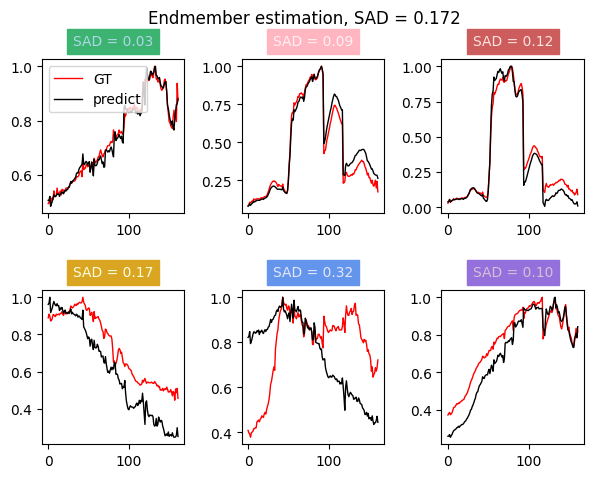

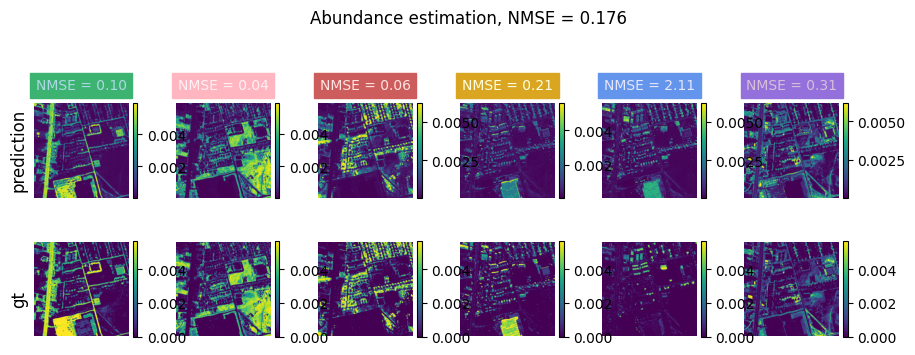

In [ ]:
epochs, lr = 200, 0.002

optim_wrapper = dict(
    optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
    constructor='LayerDecayOptimizerConstructor_ViT',
    paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9))

n_xp = 10
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)
upsampled_features = torch.zeros(n_xp, D1, new_H, new_H)

for n in range(n_xp):

    print(f"Running xp : {n}")

    model = unmx.UnmixingFromFeatures(D=D1, alpha=alpha1, H=new_H, B=B, c=c, n_features=n_features)
    model.apply(model.weights_init)
    model_dict = model.decoder.state_dict()
    model_dict["decoder.weight"][:,:,0,0] = init_e
    # model = models.init_decoder_weights(model, Y_1/Y_1.max(), c, is_unmixer=True, normalise=False)

    model = model.to(dev)
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for epoch in range(epochs):
        
        optimizer.zero_grad()

        Y = Y_1.to(dev)
        A = A_1.to(dev)
        E = E_init.to(dev)
    
        optimizer.zero_grad()
        
        Y, features = rsfm.extract_f(fm1, Y, new_H, wavelengths, use_cls=False)

        E_hat, A_hat, Y_hat = model(features)
        loss = model.loss(Y, Y_hat, A_hat, E_hat)
        
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
        optimizer.step()

        if hasattr(model, 'decoder'):
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.decoder.apply(constraints)        
    model.eval()

    with torch.no_grad():
        _, A_1, features = rsfm.extract_f(fm1, Y_1, new_H, wavelengths, A_1 ,use_cls=False)
        E_hat, A_hat, _ = model(features)

    upsampled_features[n] = model.upsample(features).reshape(D1, new_H, new_H)
    E_hats[n] = E_hat
    A_hats[n] = A_hat.squeeze(0)

E_hat_m1 = torch.mean(E_hats, dim=0)
A_hat_m1 = torch.mean(A_hats, dim=0)

sad, sad_a, mse = plots.compute_metrics_and_plot(E_hat_m1, A_hat_m1, A_1, E, normalise_E=True, normalise_A=True, return_results=True)
print(f"Average SAD = {format(sad, '.3f')}, SAD_A = {format(sad_a, '.3f')}, MSE = {format(mse, '.3f')}")

In [ ]:
from code_christophe.munkres import Munkres

def order_endmembers(E_gt, E_hat):
    if E_hat.dim() == 2:
        E_hat = E_hat.unsqueeze(0)
    if E_gt.dim() == 2:
        E_gt = E_gt.unsqueeze(0)
    
    E_hat_corr_norm = torch.zeros_like(E_hat)
    E_hat_corr = torch.zeros_like(E_hat)
    indices = torch.zeros((E_hat.size()[0],E_hat.size()[2]))

    for batch in range(E_gt.size()[0]):
    
        E0 = F.normalise(E_gt[batch,:,:],p=2.0,dim=0)
        E = F.normalise(E_hat[batch,:,:],p=2.0,dim=0)
        E0 = E0.to(torch.float32)   
        E = E.to(torch.float32)
        
        dot_products = E0.T @ E
        costmat = torch.acos(torch.clamp(dot_products, -1.0, 1.0))
        m = Munkres()
        Jperm = m.compute(costmat.tolist())
        
        EPerm = torch.zeros(E0.shape, dtype=torch.float32)
        EPerm_norm = torch.zeros(E0.shape)
        perm_indices = torch.zeros(E0.shape[1])

        print(E0.shape, EPerm.shape, E_hat.shape, len(Jperm), len(Jperm[0]), Jperm[0])
        
        for c in range(E0.shape[1]):
            EPerm[:,c] = E_hat[batch,:,Jperm[c][1]]
            EPerm_norm[:,c] = E_gt[batch, :,Jperm[c][1]]
            perm_indices[c] = Jperm[c][1]
        
        E_hat_corr_norm[batch,:,:] = EPerm_norm
        E_hat_corr[batch,:,:] = EPerm
        indices[batch,:] = perm_indices
    indices = indices.type(torch.int64)

    return E_hat_corr

feat = order_endmembers(upsampled_features[0].flatten(1).T, upsampled_features[1].flatten(1).T)

Running xp : 0
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Running xp : 1
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Running xp : 2
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Running xp : 3
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Running xp : 4
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Running xp : 5
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Running xp : 6
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Running xp : 7
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Running xp : 8
{'num_layers': 12, 'layer_decay_rate': 0.9}
Build LayerDecayOptimizerConstructor 0.900000 - 14
Running xp

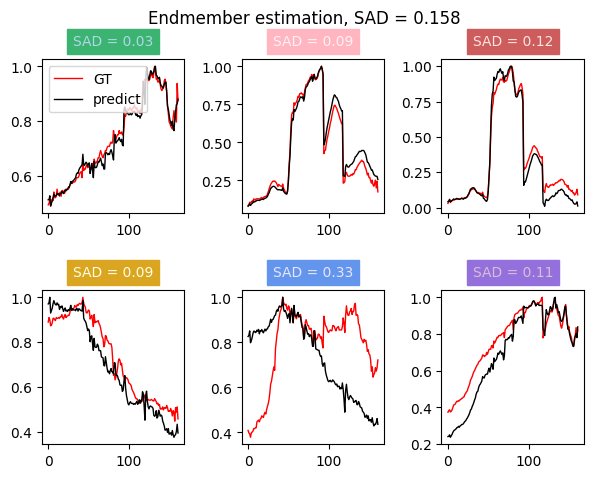

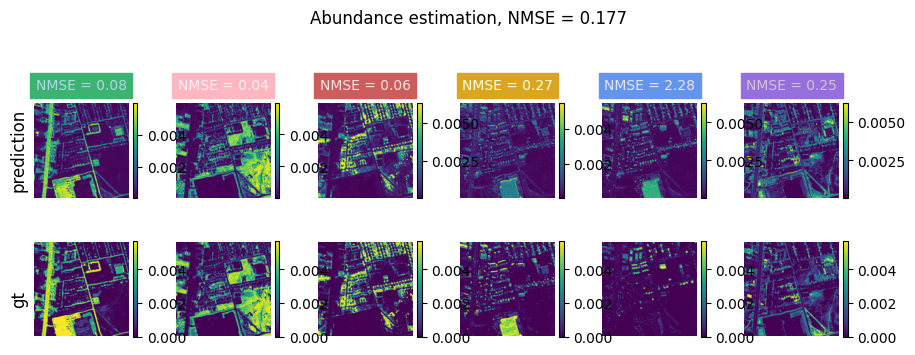

In [ ]:
shift = 2
Y_2 = Y_init[:,:,shift:224+shift, shift:224+shift]
A_2 = A_init[:,:,shift:224+shift, shift:224+shift]

fm2, Y_init_f2, new_H = rsfm.create_fm(fm_name, Y_2, n_features=n_features, use_cls=False, extend_cls=False, path=global_path, patch_size=16)
features2 = rsfm.get_dofa_features(fm2, Y_init_f2, wavelengths)
D2 = int(features2.shape[0]/1)
alpha2 = int(features2.shape[1]**0.5)
unmixer2 = unmx.UnmixingFromFeatures(D=D2, alpha=alpha2, B=B, c=c, n_features=n_features)

loader, _, _ = utils.create_dataloader(dataset, patch_size=H, dev=dev, path=global_path)
epochs, lr = 200, 0.002

optim_wrapper = dict(
    optimizer=dict(type='AdamW', lr=lr, betas=(0.9, 0.999), weight_decay=0.18),
    constructor='LayerDecayOptimizerConstructor_ViT',
    paramwise_cfg=dict(num_layers=12, layer_decay_rate=0.9))

n_xp = 10
E_hats, A_hats = torch.zeros(n_xp, B, c), torch.zeros(n_xp, c, new_H, new_H)

for n in range(n_xp):

    print(f"Running xp : {n}")

    model = unmx.UnmixingFromFeatures(D=D2, alpha=alpha2, H=new_H, B=B, c=c, n_features=n_features)
    model.apply(model.weights_init)
    model_dict = model.state_dict()
    model_dict["decoder.decoder.weight"][:,:,0,0] = init_e
    # model = models.init_decoder_weights(model, Y_2/Y_2.max(), c, is_unmixer=True, normalise=False)

    model = model.to(dev)
    optimizer = build_optim_wrapper(model, optim_wrapper)

    for epoch in range(epochs):
        
        optimizer.zero_grad()

        Y = Y_2.to(dev)
        A = A_2.to(dev)
        E = E_init.to(dev)
    
        optimizer.zero_grad()
        
        Y, features = rsfm.extract_f(fm2, Y, new_H, wavelengths, use_cls=False)

        E_hat, A_hat, Y_hat = model(features)
        loss = model.loss(Y, Y_hat, A_hat, E_hat)
        
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=10, norm_type=1)
        optimizer.step()

        if hasattr(model, 'decoder'):
            with torch.no_grad():
                constraints = models.weightConstraint()
                model.decoder.apply(constraints)        
    model.eval()

    with torch.no_grad():
        _, A_2, features = rsfm.extract_f(fm1, Y_2, new_H, wavelengths, A_2 ,use_cls=False)
        E_hat, A_hat, _ = model(features)

    E_hats[n] = E_hat
    A_hats[n] = A_hat.squeeze(0)

E_hat_m2 = torch.mean(E_hats, dim=0)
A_hat_m2 = torch.mean(A_hats, dim=0)

sad, sad_a, mse = plots.compute_metrics_and_plot(E_hat_m2, A_hat_m2, A_2, E, normalise_E=True, normalise_A=True, return_results=True)
print(f"Average SAD = {format(sad, '.3f')}, SAD_A = {format(sad_a, '.3f')}, MSE = {format(mse, '.3f')}")

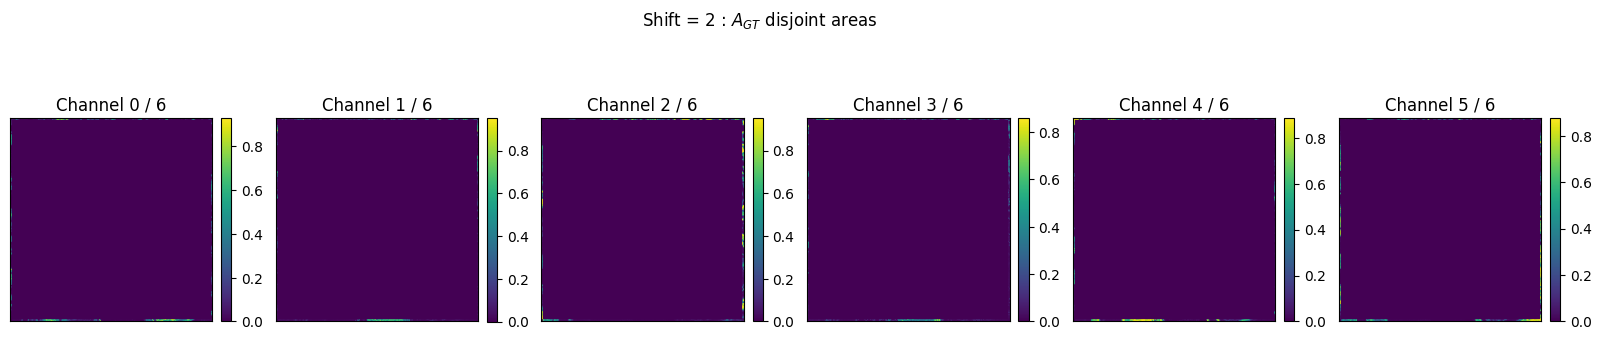

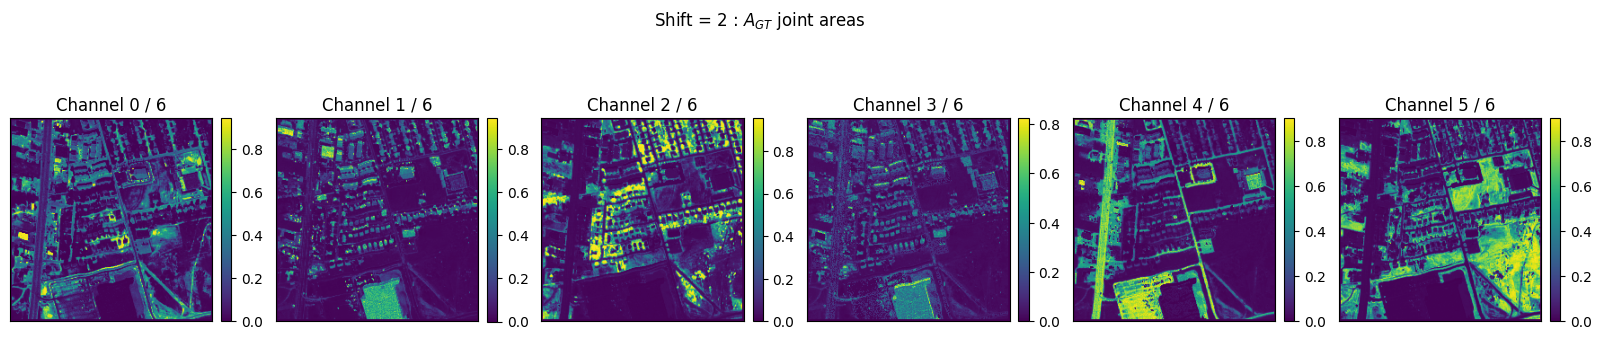

In [47]:
# shift = 2

A_disjoints = torch.zeros(c, 224+shift, 224+shift)
A_disjoints[:, :shift, :224] = A_hat_m1[:, :shift, :]
A_disjoints[: , :224:, :shift] = A_hat_m1[:, :, :shift]
A_disjoints[:, shift:, 224:] = A_hat_m2[:, :, 224-shift:]
A_disjoints[: , 224:, shift:] = A_hat_m2[:, 224-shift:, :]

A_joints = torch.zeros(c, 224+shift, 224+shift)
A_joints[:, shift:224, shift:224] = A_hat_m1[:, shift:, shift:]
A_joints[:, shift:224, shift:224] = A_hat_m2[:, :224-shift, :224-shift]

title = f"Shift = {shift} : "
title += r"$A_{GT}$ disjoint areas"
plots.plot_hsi(A_disjoints, 6, title=title)

title = f"Shift = {shift} : "
title += r"$A_{GT}$ joint areas"
plots.plot_hsi(A_joints, 6, title=title)

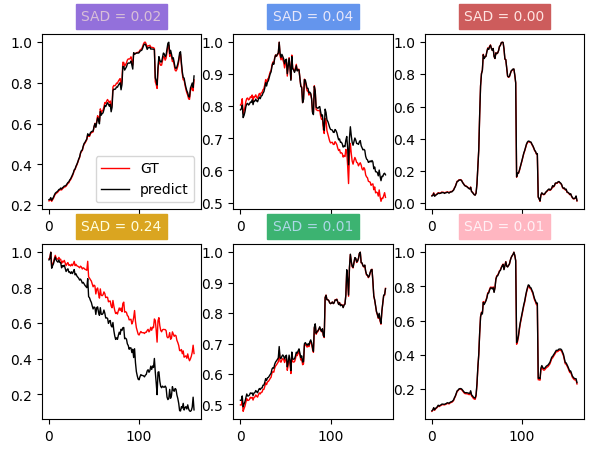

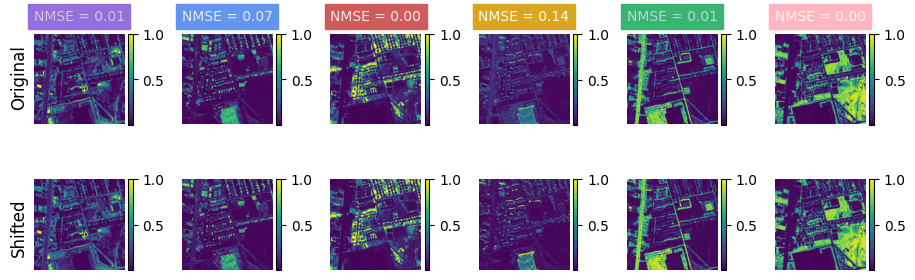

In [ ]:
n_graph = None

sad = losses.SADLoss()
mse = nn.MSELoss(reduction="sum")

bg_colors = ["mediumpurple", "cornflowerblue", "indianred", "goldenrod", "mediumseagreen", "lightpink"]
colors = ["thistle", "lavender", "mistyrose", "lightyellow", "lightblue", "lavenderblush"]

E_hat_m2_ = E_hat_m2.detach().cpu()
E_hat_m1_ = E_hat_m1.detach().cpu()
A_hat_m2_ = A_hat_m2.detach().cpu()
A_hat_m1_ = A_hat_m1.detach().cpu()
E = E.detach().cpu()
# _, A_hat_m1_, _ = utils.order_endmembers(E, E_hat_m2, A_hat_m1[:,shift:,shift:])
# _, A_hat_m2_, _ = utils.order_endmembers(E, E_hat_m2, A_hat_m2[:,:-shift,:-shift])
# A_hat_m2_ = A_hat_m2_[[4,0,2,3,1,5]]
A_hat_m1_ = A_hat_m1_[:,shift:, shift:]
A_hat_m2_ = A_hat_m2_[:,:-shift, :-shift]
# E_hat_m2_ = E_hat_m2[:, torch.tensor([4,0,2,3,1,5], device="cpu")]

if n_graph is None:
    c = A_hat_m1_.shape[0]
    n_graph = c // 2
    if c % 2 != 0: n_graph = n_graph + 1

### Endmembers ###

E_hat_m1_ = utils.normalise(E_hat_m1_, is_endmember=True)
E_hat_m2_ = utils.normalise(E_hat_m2_, is_endmember=True)
fig, axes = plt.subplots(2, n_graph, figsize=(7,5))
axes = axes.flatten()
for i in range(c):
    ax = axes[i]

    sad_val = sad(E_hat_m1_[:, i], E_hat_m2_[:, i])

    ax.plot(E_hat_m1_[:, i], 'r', linewidth=1.0, label='GT')
    ax.plot(E_hat_m2_[:, i], 'k-', linewidth=1.0, label='predict')
    ax.set_title(f"SAD = {format(sad_val, '.2f')}", fontsize=10, pad=10, backgroundcolor=bg_colors[i], color=colors[i])

    if i == 0:
        ax.legend() 

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

### Abundances ### 

if A_hat_m1_.dim() == 4:
    A_hat_m1_ = A_hat_m1_[0]

if A_hat_m2_.dim() == 4:
        A_hat_m2_ = A_hat_m2_[0]

total_sad_a = sad(A_hat_m2_.flatten(1).T, A_hat_m1_.flatten(1).T)

A_hat_m1_ = A_hat_m1_/ A_hat_m1_.amax(dim=(1,2), keepdim=True)
A_hat_m2_ = A_hat_m2_/ A_hat_m2_.amax(dim=(1,2), keepdim=True)
# A_hat_m1_ = A_hat_m1_/A_hat_m1_.max()
# A_hat_m2_ = A_hat_m2_/A_hat_m2_.max()

total_mse = mse(A_hat_m2_, A_hat_m1_)/(torch.norm(A_hat_m2_)**2)

fig, axes = plt.subplots(2, c, figsize=(10, 5))
for i in range(c):
    original = axes[0, i].imshow(A_hat_m1_[i].detach().cpu())

    mse_val = mse(A_hat_m2_[i], A_hat_m1_[i])/(torch.norm(A_hat_m2_[i])**2)

    axes[0, i].set_title(f"NMSE = {format(mse_val, '.2f')}", fontsize=10, pad=10, backgroundcolor=bg_colors[i], color=colors[i])
    axes[0, i].axis('off')

    shifted = axes[1, i].imshow(A_hat_m2_[i].detach().cpu())
    axes[1, i].axis('off')

    fig.colorbar(original, ax=axes[0,i], fraction=0.046, pad=0.04)
    fig.colorbar(shifted, ax=axes[1,i], fraction=0.046, pad=0.04)

# fig.colorbar(original, ax=axes[0, -1], fraction=0.046, pad=0.04)
fig.text(0.05, 0.7, 'Original', va='center', ha='center', fontsize=12, rotation='vertical')
fig.text(0.05, 0.4, 'Shifted', va='center', ha='center', fontsize=12, rotation='vertical')
plt.subplots_adjust(left=0.1, right=0.9, top=0.5, bottom=0.1, wspace=0.1, hspace=0.5)
fig.tight_layout(rect=[0.05, 0.25, 0.95, 0.9])
plt.subplots_adjust(wspace=0.5)
# A_title = f"Abundance estimation, NMSE = {format(total_mse, '.3f')}"
# plt.suptitle(A_title)

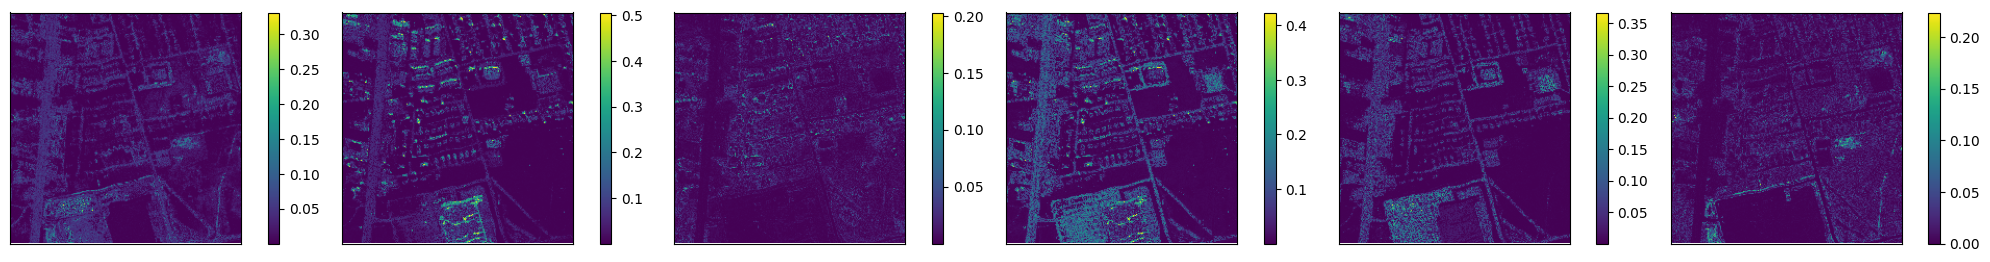

In [ ]:
# sad, sad_a, mse = plots.compute_metrics_and_plot(E_hat_m2, A_hat_m1[:,shift:, shift:], A_hat_m2[:,:-shift, :-shift], E_hat_m1, normalise_E=True, normalise_A=True, return_results=True)
# print(f"Average SAD = {format(sad, '.3f')}, SAD_A = {format(sad_a, '.3f')}, MSE = {format(mse, '.3f')}")

diff = torch.abs(A_hat_m1_ - A_hat_m2_)
fig, axs = plt.subplots(1,c, figsize=(30,3))
for i in range(c):
    im = axs[i].imshow(diff[i].detach().cpu())
    fig.colorbar(im, ax=axs[i], fraction=0.046, pad=0.04)
    
    axs[i].set_xticks([])
    axs[i].set_yticks([])
# plt.suptitle(f"NMSE between the 2 = {format(mse, '.3f')}")
plt.subplots_adjust(wspace=-0.5)